# 01 — Target Image EDA

Exploratory analysis of the *Girl with a Pearl Earring* target image (300x400 RGB).

Goals:
- Understand colour distribution (per-channel histograms)
- Identify dominant colour regions (dark background vs. subject)
- Compute baseline statistics that inform GA parameter choices
- Verify rendering and fitness pipelines work end-to-end

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.representation import IMAGE_WIDTH, IMAGE_HEIGHT, random_individual
from src.rendering import render_individual
from src.fitness import load_target, rmse, evaluate

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

Matplotlib is building the font cache; this may take a moment.


## 1. Load and display the target image

Shape: (400, 300, 3)  dtype: uint8
Pixel range: [0, 255]


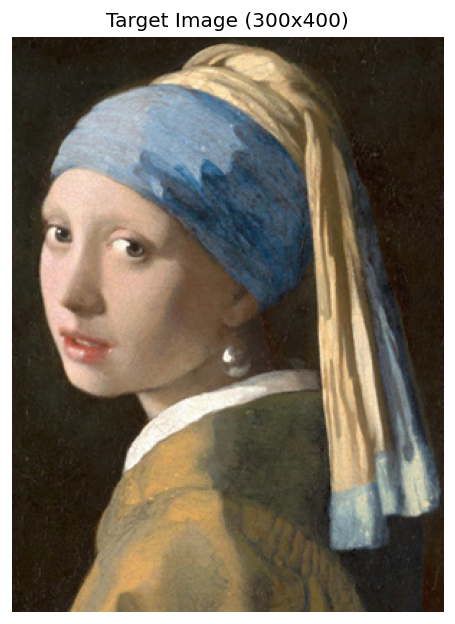

In [2]:
target = load_target("../data/target.png")
print(f"Shape: {target.shape}  dtype: {target.dtype}")
print(f"Pixel range: [{target.min()}, {target.max()}]")

fig, ax = plt.subplots(figsize=(4, 5.3))
ax.imshow(target)
ax.set_title("Target Image (300x400)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Per-channel colour histograms

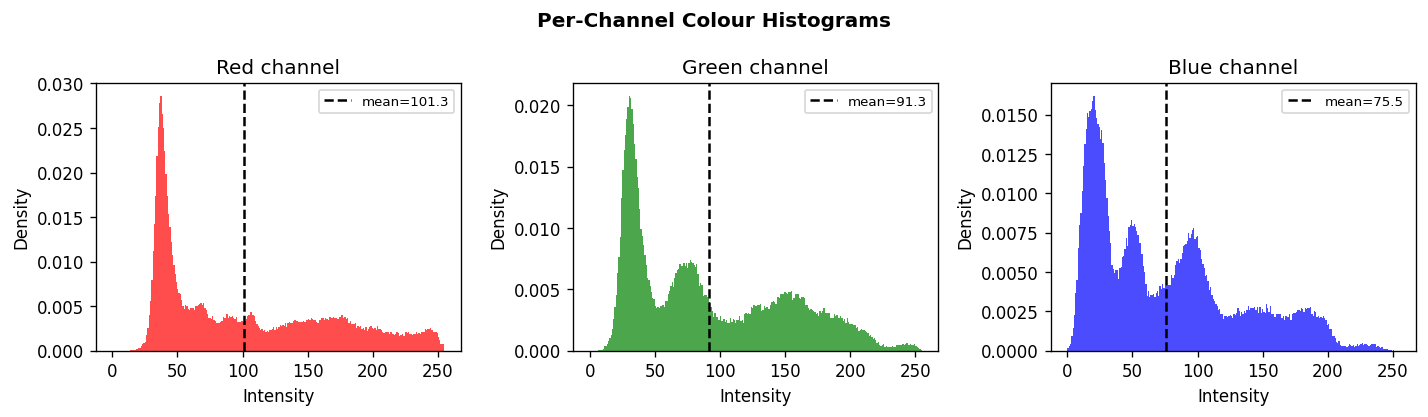

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
colors = ["red", "green", "blue"]
channel_names = ["Red", "Green", "Blue"]

for i, (ax, color, name) in enumerate(zip(axes, colors, channel_names)):
    channel = target[:, :, i].ravel()
    ax.hist(channel, bins=256, range=(0, 255), color=color, alpha=0.7, density=True)
    ax.set_title(f"{name} channel")
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Density")
    ax.axvline(channel.mean(), color="black", linestyle="--", label=f"mean={channel.mean():.1f}")
    ax.legend(fontsize=8)

plt.suptitle("Per-Channel Colour Histograms", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Summary statistics

In [4]:
print("=== Target Image Statistics ===")
print(f"Dimensions      : {IMAGE_WIDTH}x{IMAGE_HEIGHT} (W x H)")
print(f"Total pixels    : {IMAGE_WIDTH * IMAGE_HEIGHT:,}")
print(f"Total values    : {IMAGE_WIDTH * IMAGE_HEIGHT * 3:,} (RGB)")
print()
for i, name in enumerate(["Red", "Green", "Blue"]):
    ch = target[:, :, i].astype(np.float64)
    print(f"{name:5s}  mean={ch.mean():6.2f}  std={ch.std():6.2f}  "
          f"min={ch.min():.0f}  max={ch.max():.0f}  median={np.median(ch):.0f}")

print()
overall_mean = target.astype(np.float64).mean()
print(f"Overall mean intensity: {overall_mean:.2f} / 255")
print(f"Image is {'dark-biased' if overall_mean < 128 else 'light-biased'} "
      f"({overall_mean/255*100:.1f}% of max brightness)")

=== Target Image Statistics ===
Dimensions      : 300x400 (W x H)
Total pixels    : 120,000
Total values    : 360,000 (RGB)

Red    mean=101.30  std= 66.56  min=10  max=255  median=78
Green  mean= 91.26  std= 59.78  min=5  max=255  median=76
Blue   mean= 75.53  std= 56.55  min=0  max=252  median=60

Overall mean intensity: 89.36 / 255
Image is dark-biased (35.0% of max brightness)


## 4. Brightness heatmap

Shows which regions of the image are brightest/darkest. The dark background is a large uniform area — the GA should converge on it easily, while the subject's face and clothing will be harder to reconstruct.

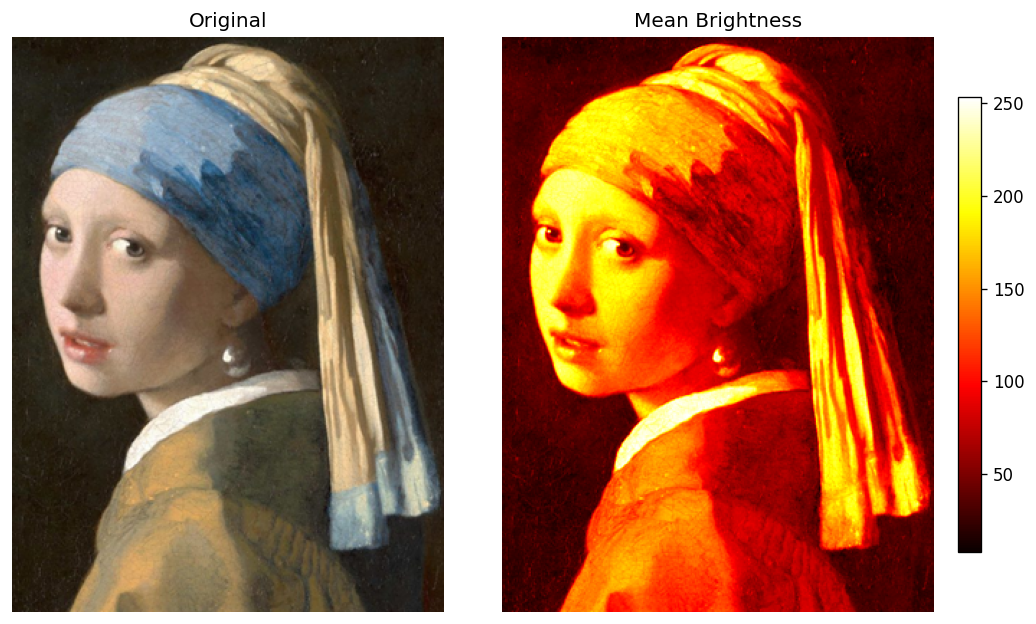

Pixels with brightness < 50: 36.9% (near-black background)


In [5]:
grayscale = target.astype(np.float64).mean(axis=2)

fig, axes = plt.subplots(1, 2, figsize=(9, 5.3))
axes[0].imshow(target)
axes[0].set_title("Original")
axes[0].axis("off")

im = axes[1].imshow(grayscale, cmap="hot")
axes[1].set_title("Mean Brightness")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

dark_frac = (grayscale < 50).sum() / grayscale.size * 100
print(f"Pixels with brightness < 50: {dark_frac:.1f}% (near-black background)")

## 5. Rendering pipeline verification

Generate a random individual, render it, and compute its RMSE against the target. This validates that the representation → rendering → fitness pipeline works end-to-end.

Individual shape: (100, 10)  (expected: (100, 10))
Rendered shape: (400, 300, 3)  dtype: uint8
Random individual RMSE: 73.7819
Black canvas RMSE:     108.7766


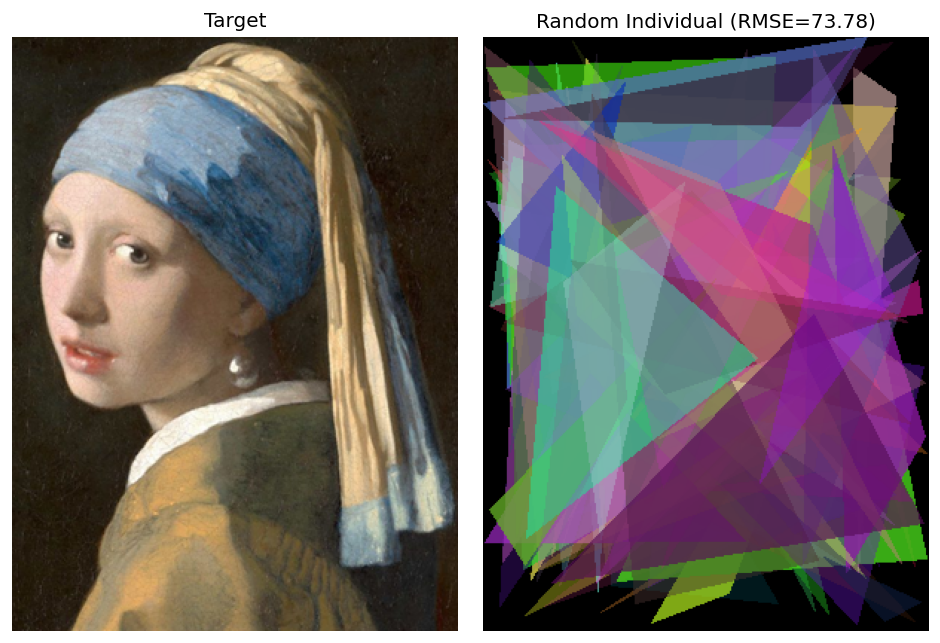

In [6]:
rng = np.random.default_rng(42)
ind = random_individual(rng)
print(f"Individual shape: {ind.shape}  (expected: (100, 10))")

rendered = render_individual(ind)
print(f"Rendered shape: {rendered.shape}  dtype: {rendered.dtype}")

fitness = evaluate(ind, target)
print(f"Random individual RMSE: {fitness:.4f}")

# Baseline: RMSE of a fully black image
black = np.zeros_like(target)
black_rmse = rmse(black, target)
print(f"Black canvas RMSE:     {black_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 5.3))
axes[0].imshow(target)
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(rendered)
axes[1].set_title(f"Random Individual (RMSE={fitness:.2f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 6. Rendering speed benchmark

Fitness evaluation is the GA bottleneck. Quick benchmark to inform population size decisions.

In [7]:
import time

n_evals = 20
start = time.perf_counter()
for _ in range(n_evals):
    evaluate(ind, target)
elapsed = time.perf_counter() - start

ms_per_eval = elapsed / n_evals * 1000
print(f"Average fitness evaluation: {ms_per_eval:.1f} ms")
print(f"Evaluations per second:    {1000 / ms_per_eval:.1f}")
print(f"Pop size 50 × 1 gen:       {ms_per_eval * 50 / 1000:.2f} s")
print(f"Pop size 100 × 1 gen:      {ms_per_eval * 100 / 1000:.2f} s")

Average fitness evaluation: 6.9 ms
Evaluations per second:    145.9
Pop size 50 × 1 gen:       0.34 s
Pop size 100 × 1 gen:      0.69 s
